Set directories and parameters

In [1]:
### PATHS AND DIRECTORIES ###
# Location of .spec files
p_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/01_compspec/SPECOUT/"
s_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral_s/01_compspec/SPECOUT/"

# Location of earthquake catalog containing stress drop estimates
delsig_catalog_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/other/shearer_2022_full_delsig_local_ecs.csv"

# Location of spectra.pkl file/where to save it
spectra_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/"


### INPUT DATA PARAMETERS ###
phase = 'p' 
# phase = 's' 
units = ['h', 'n']

# Beta computation params

# should add option to interpolate later. 
low_beta_window_p = [1, 5]
low_beta_window_s = [1, 5]
high_beta_window_p = [12, 20]
high_beta_window_s = [17, 25]
# low_f_range = [0.6667, 4.0]
# high_f_range = [14, 21.3333]
stn_f_range = [2.5, 6.0]

f_nyquist = 50.0

dist_min = 0
dist_max = 100

xsec_dmax = 1500

# perform a station correction, setting the median logbeta of these magnitudes
#     equal to zero for a single station

# calibration event parameters
calib_mag_range_p = [1.4, 1.6]
calib_mag_range_s = [1.4, 1.6]
# calib_mag_range_s = [1.9, 2.1]
calib_rmax = 5.0
calib_zmax = 1.0
calib_stn_req = 3.0
ncalib_min = 10



units = [el.upper() for el in units]



# if phase == 'p':
#     components = ['Z']
#     logbeta_name = 'logbeta_p' 
#     stn_name = 'stn_p'
#     calib_mag_range = calib_mag_range_p
#     low_beta_window = low_beta_window_p
#     high_beta_window = high_beta_window_p
# elif phase == 's':
#     components = ['N', 'E', '1', '2']
#     logbeta_name = 'logbeta_s'
#     stn_name = 'stn_s' 
#     calib_mag_range = calib_mag_range_s
#     low_beta_window = low_beta_window_s
#     high_beta_window = high_beta_window_s


In [2]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_beta_files, read_betatxt_files, read_spec_df

from tqdm import trange


In [3]:

A =     np.array([4.33E5, 3.974E6])
Ap =    np.array([4.665E5, 3.938E6])

B =     np.array([4.40E5, 3.9343E6])
Bp =    np.array([4.60E5, 3.9543E6])

Define some functions

In [4]:

def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)

def plot_poly(poly, ax, color='k'):
    poly = np.array(poly)
    n = len(poly)
    ax.plot(poly[:,0], poly[:,1], c=color)
    ax.plot([poly[-1, 0], poly[0, 0]], [poly[-1, 1], poly[0, 1]], c=color)

def compute_logbeta(spectra, low_f_ind, high_f_ind):
    # spectra is an (N x nf) array
    low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
    high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
    logbeta = high_band - low_band
    return logbeta

def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

def compute_stn(signal_spectra, noise_spectra, stn_inds):
    # signal_spectra and noise_spectra are (N x nf) 2D-arrays
    signal = np.median(signal_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    noise = np.median(noise_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    stn = signal / noise
    return stn

def get_cha(stname):
    return stname.split('.')[-1]

def get_component(cha):
    return cha[-1]

def get_units(cha):
    return cha[-2]

def get_sdir(stname):
    if stname[-1] in ['1', 'Z']:
        return 'V'
    elif stname[-1] in ['2', '3', 'N', 'E']:
        return 'H'
    else:
        raise ValueError(f"Unknown component: {stname[-1]}")

Load .spec files into a DataFrame

In [5]:
data_dir_files = os.listdir(spectra_dir)

if 'df_all' in locals():
    print("df_all already in memory")
else:
    if "spectra.pkl" in data_dir_files:
        # load pre-computed df_all DataFrame if possible
        print(f"Loading spectra.pkl...")
        t0 = time.time()
        df_all = pd.read_pickle(spectra_dir+"spectra.pkl")
        print(f"    {len(df_all):,.0f} station-event pairs loaded from spectra.pkl (t = {time.time()-t0:.3f} s)")

    else:
        spec_files = [el for el in os.listdir(p_spec_dir) if el.endswith('.spec')]
        nspec = len(spec_files)


        # Read all P-wave spectra files
        print(f"Reading P-wave .spec files from {p_spec_dir}")
        print("----------------------------------------")
        d = [[]] * nspec
        for i in trange(nspec):
            filename = spec_files[i]
            d[i] = read_spec_df(p_spec_dir+filename)
        print("Concatenating DataFrames...", end="")
        t0 = time.time()
        D_p = pd.concat(d)
        tf = time.time()
        print(f"Done ({tf-t0:.2f} s). {len(D_p)} records loaded. \n")

        # Rename to P-wave specific columns
        D_p = D_p.rename(columns={
            "s1": "p1",
            "s2": "p2",
            "nts": "nts_p"})


        ###


        s_spec_files = [el for el in os.listdir(s_spec_dir) if el.endswith('.spec')]
        s_nspec = len(s_spec_files)

        # Read all S-wave spectra files
        print(f"Reading S-wave .spec files from {s_spec_dir}")
        print("----------------------------------------")
        d = [[]] * s_nspec
        for i in trange(s_nspec):
            filename = s_spec_files[i]
            d[i] = read_spec_df(s_spec_dir+filename)
        print("Concatenating DataFrames...", end="")
        t0 = time.time()
        D_s = pd.concat(d)
        tf = time.time()
        print(f"Done ({tf-t0:.2f} s). {len(D_s)} records loaded. \n")

        # Rename to S-wave specific columns
        D_s = D_s.rename(columns={"nts": "nts_s"})

        # Merge the two dataframes together
        print("Merging P- and S-wave DataFrames...", end="")
        t0 = time.time()
        df_all = pd.merge(D_p, D_s, how='outer', on=['event_id', 'qlat', 'qlon', 'qdep','qdep','qmag','stid','slat','slon', 'selev', 'deldist'])
        tf = time.time()
        print(f"Done ({tf-t0:.2f} s). \n{len(df_all)} unique station-event pairs.\n")


        # Save the information as a pickle object
        print("Saving combined DataFrame...", end="")
        t0 = time.time()
        df_all.to_pickle(spectra_dir+"spectra.pkl")
        tf = time.time()
        print(f"Done ({tf-t0:.2f} s).")

        event_id = df['event_id'].values.astype(str)
        station_id = df['stname'].values
        nuniq = np.unique(event_id + station_id)
        assert nuniq == len(df), 'uh oh'


    # Load delsig catalog and merge into df_all
    delsig_cat_names = ["event_id", 'qyr', 'qmon', 'qday', 'qhr', 'qmn', 'qsc', 
                        "qmag", 'qlat', 'qlon', 'qdep', 'ntraces', 'ncal', 'fc', 
                        'misfit', 'delsig', 'mest', 'mw_est', 'm0', 'beta']
    delsig_cat = pd.read_csv(delsig_catalog_path, names=delsig_cat_names)
    delsig_cat = delsig_cat[['event_id', 'delsig']]

    # merge delsig_cat into df_all. Keep only records in df_all, and fill 
    #   entries in df_all without a match in delsig_cat with np.nan
    df_all = pd.merge(df_all, delsig_cat, how='left', on=['event_id'])

    # This fixes a bug where df doesn't groupby correctly when delsig is np.nan
    df_all.loc[np.isnan(df_all['delsig']), 'delsig'] = 0

Loading spectra.pkl...
    3,036,737 station-event pairs loaded from spectra.pkl (t = 58.346 s)


In [6]:
# Print out frequency information

nf = len(df_all.loc[0, 'p1'])

f = np.linspace(0, f_nyquist, nf)
dfreq = f[1] - f[0]


# calculate actual indices and bands for beta computation
low_beta_window_inds_p = np.array([np.argmin(np.abs(f - el)) for el in low_beta_window_p])
high_beta_window_inds_p = np.array([np.argmin(np.abs(f - el)) for el in high_beta_window_p])

low_beta_window_inds_s = np.array([np.argmin(np.abs(f - el)) for el in low_beta_window_s])
high_beta_window_inds_s = np.array([np.argmin(np.abs(f - el)) for el in high_beta_window_s])

low_beta_band_p = [f[low_beta_window_inds_p[0]], f[low_beta_window_inds_p[1]]]
high_beta_band_p = [f[high_beta_window_inds_p[0]], f[high_beta_window_inds_p[1]]]

low_beta_band_s = [f[low_beta_window_inds_s[0]], f[low_beta_window_inds_s[1]]]
high_beta_band_s = [f[high_beta_window_inds_s[0]], f[high_beta_window_inds_s[1]]]

# calculate actual indices and bands for STN computations
stn_inds = [np.argmin(np.abs(f - el)) for el in stn_f_range]

stn_band = [f[stn_inds[0]], f[stn_inds[1]]]


print("")
print("FREQUENCY ARRAY INFORMATION")
print("----------------------------")
print(f"Frequency array ranges from {f[0]:.2f} to {f[-1]:.2f} Hz with {len(f)} elements (df = {dfreq:.3f} Hz). ")
print("")
print(f"Desired | Actual low-frequency band (P waves):   {low_beta_window_p[0]:7.3f} -{low_beta_window_p[1]:7.3f} Hz | {low_beta_band_p[0]:7.3f} -{low_beta_band_p[1]:7.3f} Hz")
print(f"Desired | Actual high-frequency band (P waves):  {high_beta_window_p[0]:7.3f} -{high_beta_window_p[1]:7.3f} Hz | {high_beta_band_p[0]:7.3f} -{high_beta_band_p[1]:7.3f} Hz")
print("")
print(f"Desired | Actual low-frequency band (S waves):   {low_beta_window_s[0]:7.3f} -{low_beta_window_s[1]:7.3f} Hz | {low_beta_band_s[0]:7.3f} -{low_beta_band_s[1]:7.3f} Hz")
print(f"Desired | Actual high-frequency band (S waves):  {high_beta_window_s[0]:7.3f} -{high_beta_window_s[1]:7.3f} Hz | {high_beta_band_s[0]:7.3f} -{high_beta_band_s[1]:7.3f} Hz")
print("")
print(f"Desired | Actual signal-to-noise band: {stn_f_range[0]:7.3f} -{stn_f_range[1]:7.3f} Hz | {stn_band[0]:7.3f} -{stn_band[1]:7.3f} Hz")



FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 65 elements (df = 0.781 Hz). 

Desired | Actual low-frequency band (P waves):     1.000 -  5.000 Hz |   0.781 -  4.688 Hz
Desired | Actual high-frequency band (P waves):   12.000 - 20.000 Hz |  11.719 - 20.312 Hz

Desired | Actual low-frequency band (S waves):     1.000 -  5.000 Hz |   0.781 -  4.688 Hz
Desired | Actual high-frequency band (S waves):   17.000 - 25.000 Hz |  17.188 - 25.000 Hz

Desired | Actual signal-to-noise band:   2.500 -  6.000 Hz |   2.344 -  6.250 Hz


Load data, index events and stations, and filter out bad results. This is to setup for the inverse problem.

In [ ]:


# These are columns that are station-dependent, event-dependent, and 
# both-dependent. pandas pivot_table might be useful here
st_dep = ['stname', 'slat', 'slon', 'selev']
# ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep", "nts_p", "nts_s", 'delsig']
ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep", 'delsig']
dependents = ['deldist', 'p1', 'p2', 's1', 's2', 'logbeta_p', 'logbeta_s']

print("-----------------------------")
print("---    DATA PROCESSING    ---")
print("-----------------------------")
    
print("\nFiltering out records based on user-specified criteria...")
print("---------------------------------------------------------")

# df/df_all has one row per station-event pair
df = df_all.copy()
df = df.rename(columns={"stid":"stname"})

df = df.drop(columns=['nts_p', 'nts_s'])

# get initial number of records
npairs_initial = len(df)
nevents_initial = len(np.unique(df['event_id']))
nstations_initial = len(np.unique(df['stname']))
print(f"{npairs_initial:,.0f} records in total. {nevents_initial:,.0f} events, {nstations_initial:,.0f} stations.")

# remove events below the lower calibration event magnitude, since these are unused for all future steps
t0 = time.time()
df = df[df['qmag'] >= calib_mag_range[0]].reset_index(drop=True)
npairs = len(df)
print(f"{npairs_initial - npairs:,.0f} pairs with qmag < M{calib_mag_range[0]:.2} removed (t = {time.time()-t0:.3f} s). {len(df):,.0f} remaining.")

# remove distant event-station records
t0 = time.time()
df = df[df['deldist'] <= dist_max].reset_index(drop=True)
print(f"{npairs - len(df):,.0f} pairs with deldist > {dist_max} removed (t = {time.time()-t0:.3f} s). {len(df):,.0f} remaining.")

# get cha, component, and unit columns
t0 = time.time()
df['cha'] = df['stname'].apply(get_cha)
df['component'] = df['cha'].apply(get_component)
df['unit'] = df['cha'].apply(get_units)
print(f"Computed cha, component, and unit columns (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

# # remove components not in 'components' object ('N', 'E', 'Z', for example)
# t0 = time.time()
# l1 = len(df)
# nstations = len(np.unique(df['stname']))
# df = df[np.any([df['component'].values==el for el in components], axis=0)].reset_index(drop=True)
# print(f"{l1-len(df):,.0f} records, {nstations-len(np.unique(df['stname']))} stations removed (component not in {components}) (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

# add a column 'sdir' for direction, either 'H' or 'V', for horizontal or 
# vertical, based on the last character of the stname. 'N', 'E', '2', and '3'
# should be horizontal, '1' and 'Z' should be vertical


t0 = time.time()
df['sdir'] = df['stname'].apply(get_sdir)
print(f"Computed sdir column (t = {time.time()-t0:.2} s). {len(df[df['sdir']=='H']):,.0f} horizontal, {len(df[df['sdir']=='V']):,.0f} vertical records")
st_dep += ['sdir']

nevents = len(np.unique(df['event_id']))
nstations = len(np.unique(df['stname']))
print(f"{nevents:,.0f} events remaining, {nstations:,.0f} stations remaining.")

# remove units not in 'unit' object ('H', 'N', for example)
t0 = time.time()
l1 = len(df)
df = df[np.any([df['unit'].values==el for el in units], axis=0)].reset_index(drop=True)
print(f"{l1-len(df):,.0f} records removed (unit not in {units}) (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

# drop these columns
df = df.drop(columns=['cha', 'component', 'unit']).reset_index(drop=True)

# # # explode!
# # df = df_sta.explode(ev_dep + dependents)
df['event_id'] = df['event_id'].astype(int)
df['qmag'] = df['qmag'].astype(float)
df['qlat'] = df['qlat'].astype(float)
df['qlon'] = df['qlon'].astype(float)
df['qdep'] = df['qdep'].astype(float)
df['slat'] = df['slat'].astype(float)
df['slon'] = df['slon'].astype(float)
df['selev'] = df['selev'].astype(float)
df['deldist'] = df['deldist'].astype(float)
# df['nts_p'] = df['nts_p'].astype(float)
# df['nts_s'] = df['nts_s'].astype(float)
df['delsig'] = df['delsig'].astype(float)

df['logbeta_p'] = np.nan
df['logbeta_s'] = np.nan

# Compute sx and sy (station easting and northing)
t0 = time.time()
df['sx'], df['sy'], zn, zl = utm.from_latlon(
    df['slat'].values, 
    df['slon'].values
    )
st_dep += ['sx', 'sy']
df.reset_index(drop=True, inplace=True)

# Compute qxs and qys of events (event eastings and northings)
df['qx'], df['qy'], zn, zl = utm.from_latlon(
    df['qlat'].values, 
    df['qlon'].values
    )
ev_dep += ['qx', 'qy']
df.reset_index(drop=True, inplace=True)
print(f"Earthquake and station eastings and westings computed (t = {time.time()-t0:.3f} s)")

# # make sure each earthquake has enough remaining records
# df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
# df_ev = df_ev[df_ev['stname'].map(len) >= nrecords_min].reset_index(drop=True)
# print(f"{int(nevents_initial-len(df_ev))} events removed due to not enough"
#     f" records (needs >= {nrecords_min})")

# group by station in df_sta and add 'stind' column, unique for each station
t0 = time.time()
df_sta = df.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)
df_sta['stind'] = df_sta.index.values.astype(int)
st_dep += ['stind']
print(f"Grouped by station (t = {time.time()-t0:.3f} s). {len(df_sta):,.0f} stations remaining.")

t0 = time.time()
df = df_sta.explode(ev_dep + dependents)
df.reset_index(drop=True, inplace=True)
print(f"Exploded (t = {time.time()-t0:.3f} s)")

df['event_id'] = df['event_id'].astype(int)
df['qmag'] = df['qmag'].astype(float)
df['qlat'] = df['qlat'].astype(float)
df['qlon'] = df['qlon'].astype(float)
df['qdep'] = df['qdep'].astype(float)
df['slat'] = df['slat'].astype(float)
df['slon'] = df['slon'].astype(float)
df['selev'] = df['selev'].astype(float)
df['deldist'] = df['deldist'].astype(float)
# df['nts_p'] = df['nts_p'].astype(float)
# df['nts_s'] = df['nts_s'].astype(float)
df['qx'] = df['qx'].astype(float)
df['qy'] = df['qy'].astype(float)
df['sx'] = df['sx'].astype(float)
df['sy'] = df['sy'].astype(float)
df['delsig'] = df['delsig'].astype(float)
df['logbeta_p'] = df['logbeta_p'].astype(float)
df['logbeta_s'] = df['logbeta_s'].astype(float)

# save the events within calibration M range for later
df_calib = df[np.logical_and(df['qmag'] >= calib_mag_range[0], df['qmag'] < calib_mag_range[1])].reset_index(drop=True)

# group by event
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)

# get a list of event ids that are in df['event_id'] but not in df_ev['event_id'] 
absent = df[~df['event_id'].isin(df_ev['event_id'])].reset_index(drop=True)

assert nevents-len(df_ev)==0, 'Uh oh: missing events'
assert len(np.unique(absent['event_id']))==0, 'Uh oh: missing events'

# nevents = len(np.unique(df['event_id']))
# evs1 = df.copy()
# nstations = len(np.unique(df['stname']))
# print(f"{nevents:,.0f} events remaining, {nstations:,.0f} stations remaining.")


nevents = len(df_ev)
nstations = len(df_sta)
ndata = len(df)

print("-------------")
print("Final counts:")
print("-------------")
print(f"{nevents:,.0f} of {nevents_initial:,.0f} events ({nevents/nevents_initial*100:.1f}%)")
print(f"{nstations:,.0f} of {nstations_initial:,.0f} stations ({nstations/nstations_initial*100:.1f}%)")
print(f"{ndata:,.0f} of {npairs_initial:,.0f} records ({ndata/npairs_initial*100:.1f}%)")
print("")
print("Calibration events:")
print("-------------------")
print(f"{len(df_calib):,.0f} records of {len(np.unique(df_calib['event_id'])):,.0f} events between M {calib_mag_range[0]:.2f} and {calib_mag_range[1]:.2f}")


-----------------------------
---    DATA PROCESSING    ---
-----------------------------

Filtering out records based on user-specified criteria...
---------------------------------------------------------
3,036,737 records in total. 12,936 events, 522 stations.
1,056,460 pairs with qmag < M1.4 removed (t = 0.812 s). 1,980,277 remaining.
215,187 pairs with deldist > 100 removed (t = 0.666 s). 1,765,090 remaining.
Computed cha, component, and unit columns (t = 1.2 s). 1,765,090 remaining.
Computed sdir column (t = 0.4 s). 1,091,941 horizontal, 673,149 vertical records
8,526 events remaining, 447 stations remaining.
0 records removed (unit not in ['H', 'N']) (t = 1.1 s). 1,765,090 remaining.
Earthquake and station eastings and westings computed (t = 0.712 s)
Grouped by station (t = 6.253 s). 447 stations remaining.
Exploded (t = 2.917 s)
-------------
Final counts:
-------------
8,526 of 12,936 events (65.9%)
447 of 522 stations (85.6%)
1,765,090 of 3,036,737 records (58.1%)

Calibratio

In [ ]:
## Compute logbeta values for P- and S-wave spectra

# find indices of horizontal and vertical records
h_ind = np.where(df['sdir'].values == 'H')[0]
v_ind = np.where(df['sdir'].values == 'V')[0]

# find indices of records with non-NaN P- and S-wave spectra
p_spec_ind = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
s_spec_ind = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]

# Set the indices for P- and S-waves
df_p_inds = np.intersect1d(h_ind, p_spec_ind)
df_s_inds = np.intersect1d(v_ind, s_spec_ind)

# compute logbeta for P-wave spectra
print("Computing logbeta for P-waves...", end='')
t0 = time.time()
p2 = np.vstack(df['p2'].values[df_p_inds], dtype=float)

logbeta_p = compute_logbeta(p2, low_beta_window_inds, high_beta_window_inds)
df['logbeta_p'] = np.nan
df.loc[df_p_inds, 'logbeta_p'] = logbeta_p
print(f"done (t = {time.time()-t0:.3f} s)")

# now do it for S-waves
print("Computing logbeta for S-waves...", end='')
t0 = time.time()
s2 = np.vstack(df['s2'].values[df_s_inds], dtype=float)

logbeta_s = compute_logbeta(s2, low_beta_window_inds, high_beta_window_inds)
df['logbeta_s'] = np.nan 
df.loc[df_s_inds, 'logbeta_s'] = logbeta_s
print(f"done (t = {time.time()-t0:.3f} s)")
dependents += ['logbeta_p', 'logbeta_s']

Computing logbeta for P-waves...done (t = 11.977 s)
Computing logbeta for S-waves...done (t = 12.708 s)


In [45]:
a = [hasattr(el, '__len__') and df['sdir'].values[i] == 'H' for i, el in enumerate(df['p2'].values)]

In [46]:
a = [hasattr(el, '__len__') for el in df['p2'].values ]

In [48]:
set(np.where(df['sdir'].values == 'H')[0]) & set([hasattr(el, '__len__') for el in df['p2'].values ])

{False, True}

In [49]:
np.where(df['sdir'].values == 'H')[0]

array([      0,       1,       2, ..., 1764208, 1764209, 1764210])

In [52]:
np.intersect1d(np.where(df['sdir'].values == 'H')[0], np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0])

array([      0,       1,       2, ..., 1764206, 1764208, 1764209])

In [ ]:
h_ind = np.where(df['sdir'].values == 'H')[0]
p_spec_ind = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
df_p_inds = np.intersect1d(h_ind, p_spec_ind)

v_ind = np.where(df['sdir'].values == 'V')[0]
s_spec_ind = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
df_s_inds = np.intersect1d(v_ind, s_spec_ind)

In [51]:
[hasattr(el, '__len__') for el in df['p2'].values ]

[True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 Fa

In [22]:
df['stname'].values[df_s_inds]

array(['CE.34349..HNZ', 'CE.34349..HNZ', 'CE.34349..HNZ', ...,
       'ZY.SV08.CC.HNZ', 'ZY.SV08.CC.HNZ', 'ZY.SV08.CC.HNZ'], dtype=object)

In [9]:
## Compute STN values for P- and S-wave spectra

# find indices where spectra are non-NaN, stack into 2D-array
# should get equivalent result using either p1 or p2 columns
print("Computing STN for P-waves...", end='')
t0 = time.time()
df_p_inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
p2 = np.vstack(df['p2'].values[df_p_inds], dtype=float)
p1 = np.vstack(df['p1'].values[df_p_inds], dtype=float)

# compute stn for each row in the 2D-array
stn = compute_stn(p2, p1, stn_inds)
df['stn_p'] = np.nan 
df.loc[df_p_inds, 'stn_p'] = stn
print(f"done (t = {time.time()-t0:.3f} s)")

# now for S-wave spectra
print("Computing STN for S-waves...", end='')
t0 = time.time()
df_s_inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
s2 = np.vstack(df['s2'].values[df_s_inds], dtype=float)
s1 = np.vstack(df['s1'].values[df_s_inds], dtype=float)

# compute stn for each row in the 2D-array 
stn = compute_stn(s2, s1, stn_inds)
df['stn_s'] = np.nan 
df.loc[df_s_inds, 'stn_s'] = stn
print(f"done (t = {time.time()-t0:.3f} s)")
dependents += ['stn_p', 'stn_s']

Computing STN for P-waves...done (t = 9.421 s)
Computing STN for S-waves...done (t = 10.251 s)


In [10]:
# p_stn = p2/p1 
# s_stn = s2/s1

# p_stn_median = np.median(p_stn, axis=0)
# s_stn_median = np.median(s_stn, axis=0)

# plt.figure()
# plt.plot(f, p_stn[::1000,:].T, 'k', linewidth=0.1)
# plt.plot(f, p_stn_median, 'r', linewidth=2)
# plt.yscale('log')
# plt.xscale('log')
# plt.axhline(1, color='k', linewidth=2)
# plt.title("P-wave STN (1/1000th of records)")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("STN")
# plt.show()

# plt.figure()
# plt.plot(f, s_stn[::1000,:].T, 'k', linewidth=0.1)
# plt.plot(f, s_stn_median, 'r', linewidth=2)
# plt.axhline(1, color='k', linewidth=2)
# plt.yscale('log')
# plt.xscale('log')
# plt.title("S-wave STN (1/1000th of records)")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("STN")
# plt.show()

# print(p_stn.shape, s_stn.shape)




Visualize the signal-to-noise of the calibration event records

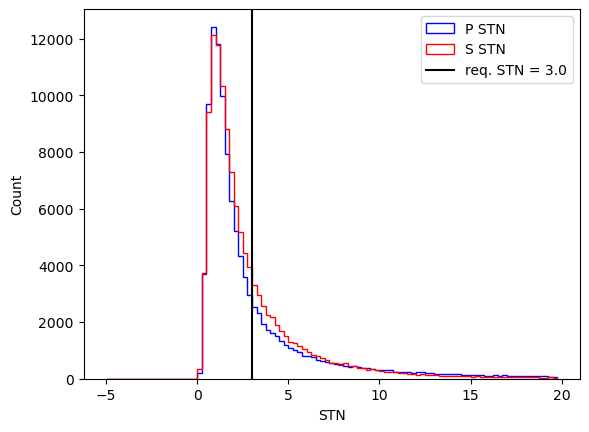

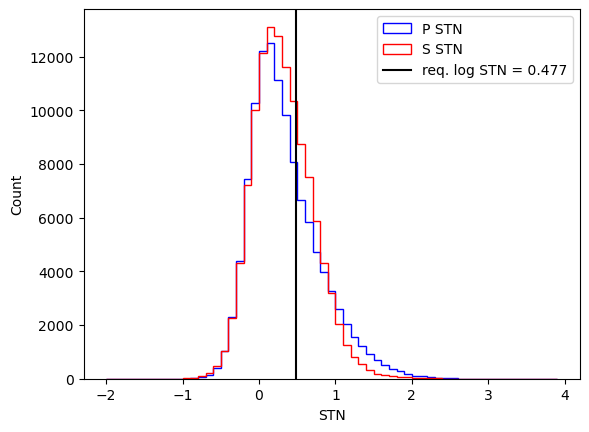

In [11]:
bins = np.arange(-5, 20, 0.25)
logbins = np.arange(-2, 4, 0.1)
df_calib = df[np.logical_and(df['qmag'] >= calib_mag_range[0], df['qmag'] < calib_mag_range[1])].reset_index(drop=True)

plt.figure()
plt.hist((df_calib['stn_p']), bins=bins, histtype='step', color='b', label='P STN')
plt.hist((df_calib['stn_s']), bins=bins, histtype='step', color='r', label='S STN')
plt.axvline(calib_stn_req, color='k', label=f"req. STN = {calib_stn_req:.1f}")
plt.legend()
plt.xlabel("STN")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(np.log10(df_calib['stn_p']), bins=logbins, histtype='step', color='b', label='P STN')
plt.hist(np.log10(df_calib['stn_s']), bins=logbins, histtype='step', color='r', label='S STN')
plt.axvline(np.log10(calib_stn_req), color='k', label=f"req. log STN = {np.log10(calib_stn_req):.3f}")
plt.legend()
plt.xlabel("STN")
plt.ylabel("Count")
plt.show()



In [12]:

# Indices of records that have P- or S-wave spectra
df_p_inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
df_s_inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]

# Indices of calibration records that have P- or S-wave spectra
df_calib_inds_p = np.where([hasattr(el, '__len__') for el in df_calib['p2'].values ])[0]
df_calib_inds_s = np.where([hasattr(el, '__len__') for el in df_calib['s2'].values ])[0]

# Perform corrections using calibration events

# if phase == 'p':
#     spec = np.vstack(df['p2'].values[df_p_inds], dtype=float)
#     df_spec_inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
#     calib_spec = np.vstack(df_calib['p2'].values[df_calib_inds_p], dtype=float)
#     df_calib_inds = df_calib_inds_p
# elif phase == 's':
#     spec = np.vstack(df['s2'].values[df_s_inds], dtype=float)
#     df_spec_inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
#     calib_spec = np.vstack(df_calib['s2'].values[df_calib_inds_s], dtype=float)
#     df_calib_inds = df_calib_inds_s

# DataFrame containing all records of events greater than the largest 
# calibration event. These are the target events.
df_target_ev = df_ev[df_ev['qmag'] >= calib_mag_range[1]].reset_index(drop=True)

print(f"{len(df_target_ev):,.0f} target events with M >= {calib_mag_range[1]} ({len(df[df['qmag'] >= calib_mag_range[1]]):,.0f} records)")
print(f"{len(np.unique(df_calib['event_id'])):,.0f} calibration events with {calib_mag_range[0]} <= M < {calib_mag_range[1]} ({len(df_calib):,.0f} records)")


df_target_ev['dlogbeta_p'] = np.nan
df_target_ev['dlogbeta_s'] = np.nan

# DataFrames with _ev suffix are grouped by event (i.e. one event per row)
# Otherwise, DataFrames have one row per record (station/event combination)

# raise ValueError()

# loop over each target event
# for nev in trange(len(df_target_ev), desc="Computing corrected logbeta"):
for nev in range(100):

    # Store the entire row of the target event
    row = df_target_ev.loc[nev]

    # Store a copy of the calibration event records DataFrame
    df_c = df_calib.copy()

    # Get all records in df relating to target event_id
    df_target = df[df['event_id'] == row['event_id']].reset_index(drop=True)

    
    # Filter out calibration event records that:
    #   1) are too shallow or too deep
    #   2) don't share stations with the target event
    #   3) are too low signal-to-noise ratio
    keep_bool = np.all([
        df_c['qdep']>=row['qdep']-calib_zmax, 
        df_c['qdep']<=row['qdep']+calib_zmax,
        np.isin(df_c['stind'].values, row['stind']),
        df_c[stn_name] >= calib_stn_req,
        ], axis=0)
    df_c = df_c[keep_bool].reset_index(drop=True)

    # 'index' column in df_c is the index of the calibration event in df_calib
    
    # rough filter to avoid computing distances for all calibration events (slightly faster)
    keep_bool = np.all([
        np.abs(df_c['qx']-row['qx']) <= calib_rmax*1000,
        np.abs(df_c['qy']-row['qy']) <= calib_rmax*1000,
    ], axis=0)
    df_c = df_c[keep_bool].reset_index(drop=True)

    # compute station-event distance 
    df_c['tdist'] = np.sqrt((row['qx'] - df_c['qx'].values)**2 + (row['qy'] - df_c['qy'].values)**2)

    # filter out calibration events that are too far from the target event
    df_c = df_c[df_c['tdist'] <= calib_rmax*1000].reset_index(drop=True)

    ncalib = len(np.unique(df_c['event_id'].values))

    # added 'index'
    df_c = df_c[['stname','stind', 'event_id', 'logbeta_p', 'logbeta_s']]

    if ncalib >= ncalib_min:
        df_target_pre = df_target.copy()
        df_target = pd.merge(df_target, df_c, how='inner', on='stind', suffixes=['_t','_c'])
        
        df_target['dlogbeta_p'] = df_target[f'logbeta_p_t'] - df_target[f'logbeta_p_c']
        df_target['dlogbeta_s'] = df_target[f'logbeta_s_t'] - df_target[f'logbeta_s_c']
        print(len(df_target) - np.sum(np.isnan(df_target['dlogbeta_p'])), len(df_target) - np.sum(np.isnan(df_target['dlogbeta_s'])))
        if len(df_target) - np.sum(np.isnan(df_target['dlogbeta_p'])) > ncalib_min:
            df_target_ev.at[nev,'dlogbeta_p'] = np.nanmedian(df_target['dlogbeta_p'])
        if len(df_target) - np.sum(np.isnan(df_target['dlogbeta_s'])) > ncalib_min:
            df_target_ev.at[nev,'dlogbeta_s'] = np.nanmedian(df_target['dlogbeta_s'])

        # if np.sum(np.isnan(df_target['dlogbeta_p']))>0 or np.sum(np.isnan(df_target['dlogbeta_s']))>0:
        #     print(f"{np.sum(np.isnan(df_target['dlogbeta_p']))} of {len(df_target)} NaN values in df_target['dlogbeta_p'], {np.sum(np.isnan(df_target['dlogbeta_s']))} of {len(df_target)} NaN values in df_target['dlogbeta_p'], df_target['dlogbeta_s']")
        #     print(f"\t{df_target_ev.at[nev,'dlogbeta_p']:.4f}, {df_target_ev.at[nev,'dlogbeta_s']:.4f}")


# indices where dlogbeta_x was calculated
keep_p = ~np.isnan(df_target_ev['dlogbeta_p'])
keep_s = ~np.isnan(df_target_ev['dlogbeta_s'])

# ds = df_target_ev[~np.isnan(df_target_ev['dlogbeta_p'])].reset_index(drop=True)
ds['dlogbeta_p_corr'] = ds['dlogbeta_p'].values
ds['dlogbeta_s_corr'] = ds['dlogbeta_s'].values

edges = np.arange(1, 7.3, 0.2)

for i in range(len(edges)-1):
    inrange = np.logical_and(ds['qmag']>=edges[i], ds['qmag']<edges[i+1])
    keep_p = np.logical_and(inrange, keep_p)
    keep_s = np.logical_and(inrange, keep_s)
    if np.sum(keep_p) > 0:
        dlogbeta_p = ds[keep_p]['dlogbeta_p'].values
        ds.loc[keep_p, 'dlogbeta_p_corr'] -= np.nanmedian(dlogbeta_p)
    if np.sum(keep_s) > 0:
        dlogbeta_s = ds[keep_s]['dlogbeta_s'].values
        ds.loc[keep_s, 'dlogbeta_s_corr'] -= np.nanmedian(dlogbeta_s)

# remove records with delsig==0
ds = ds[ds['delsig'] != 0].reset_index(drop=True)

corrcoef_p = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_p_corr'].values)[0,1]
corrcoef_s = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_s_corr'].values)[0,1]


txt = '\n'.join([
    f"P correlation: {corrcoef_p:.4f}", 
    f"S correlation: {corrcoef_s:.4f}",
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"Calib. STN band:  {stn_band[0]:.1f}-{stn_band[1]:.1f} Hz",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])

plt.figure()
ax = plt.gca()
plt.scatter(ds['delsig'], ds['dlogbeta_p_corr'], c=ds['qmag'], s=3, marker='.')
plt.xscale('log')
plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Stress drop (MPa)')
plt.ylabel('Corrected logbeta')
# plt.savefig(f"figs/corr/{n}_{phase}_correlation.pdf")
plt.show()
plt.close()



6,777 target events with M >= 1.6 (480,023 records)
1,749 calibration events with 1.4 <= M < 1.6 (129,561 records)
532 510
555 547
243 248
306 289
539 550
718 873
307 315
94 119
609 655
750 673
726 943
172 196
686 765
917 931
65 52
1211 1238
861 860
563 571
919 911
599 541
1115 1164
999 935
749 748
659 688
509 499
957 989
556 537
662 584
955 932
175 196
192 238
563 567
602 585
537 529
820 784
792 776
920 923
835 746
732 750
111 110
966 919
1033 1073
1098 1072
1470 1481
999 978
130 127
631 597
922 914
146 142
688 660
623 619
195 207
135 150
944 910
611 561
673 722
657 724
461 456
630 645
557 509
371 368
1022 1002
1034 986
1084 1054
771 753
2012 2004
295 278
878 852
594 575
1309 1297
1702 1658
422 416
153 141
2095 1985
435 452
854 835
957 941
1062 1040
285 281
799 771
1148 1128
1374 1236
323 318
1099 1080
369 355


NameError: name 'ds' is not defined

In [108]:
np.isnan(df_target_ev['dlogbeta_p'])

0       False
1       False
2        True
3       False
4       False
        ...  
6772     True
6773     True
6774     True
6775     True
6776     True
Name: dlogbeta_p, Length: 6777, dtype: bool

In [99]:
len(df_target) - np.sum(np.isnan(df_target['dlogbeta_p']))

np.int64(1899)

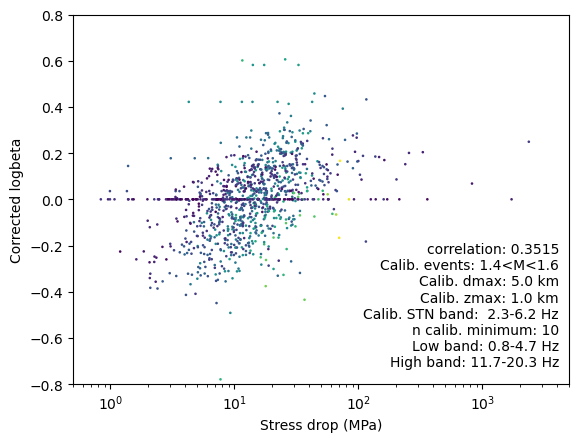

In [57]:

# remove records with delsig==0
ds = ds[ds['delsig'] != 0].reset_index(drop=True)

corrcoef = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_corr'].values)[0,1]


txt = '\n'.join([
    f"correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"Calib. STN band:  {stn_band[0]:.1f}-{stn_band[1]:.1f} Hz",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])

plt.figure()
ax = plt.gca()
plt.scatter(ds['delsig'], ds['dlogbeta_corr'], c=ds['qmag'], s=3, marker='.')
plt.xscale('log')
plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Stress drop (MPa)')
plt.ylabel('Corrected logbeta')
# plt.savefig(f"figs/corr/{n}_{phase}_correlation.pdf")
plt.show()
plt.close()

In [55]:
# three DataFrames: df_target, df_target_pre, df_c. Merge:
# df_target = pd.merge(df_target_pre, df_c, how='inner', on='stind', suffixes=['_t','_c'])
# inner merge: use intersection of keys from both frames, similar to a SQL inner join; preserve the order of the left keys.
print("df_target_pre, event 17850492:")
print(df_target_pre[['stname', 'event_id', 'stind', 'logbeta_p', 'logbeta_s']])

print("df_c, containing all records of events near 17850492 passing STN requirements:")
print(df_c)

print("df_target, which, for each unique station in df_target pre, should have the number of matching stations in df_c:")
print(df_target)

# the merge should match these by station, so that for each station in df_target_pre, 

df_target_pre, event 17850492:
          stname  event_id  stind  logbeta_p  logbeta_s
0    CI.APL..HNZ  17850492      3   0.772430   0.583847
1    CI.CCA..HHZ  17850492      6  -1.247182  -0.692191
2    CI.CCA..HNZ  17850492      7  -1.610432        NaN
3    CI.CCC..HHZ  17850492      8  -0.775502  -0.600783
4    CI.CCC..HNZ  17850492      9  -0.875005  -0.596906
..           ...       ...    ...        ...        ...
61   NN.QSM..HHZ  17850492    111  -0.175636  -0.913791
62  PB.B916..EHZ  17850492    115  -0.567387  -1.167730
63  PB.B917..EHZ  17850492    116  -0.602366  -0.375060
64  PB.B918..EHZ  17850492    117  -0.091656  -0.827441
65  PB.B921..EHZ  17850492    118  -0.096926  -0.462293

[66 rows x 5 columns]
df_c, containing all records of events near 17850492 passing STN requirements:
           stname  stind  event_id  logbeta_p
0     CI.APL..HNZ      3  37241580   0.749883
1     CI.APL..HNZ      3  38483639   0.441903
2     CI.APL..HNZ      3  38563447   0.721867
3     CI.CC

In [51]:
df_target_pre['event_id'].unique()

array([17850492])

In [42]:
df_target

,stname_t,slat,slon,selev,sx,sy,event_id_t,qmag,qlon,qlat,...,s2,logbeta_p_t,logbeta_s,stind,stn_p,stn_s,stname_c,event_id_c,logbeta_p_c,dlogbeta
0,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,17850492,2.05,-117.552719,35.641129,...,"[1.2965055873337406e-07, 2.134130028252912e-07...",0.772430,0.583847,3,2.382124,3.233079,CI.APL..HNZ,37241580,0.749883,0.022547
1,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,17850492,2.05,-117.552719,35.641129,...,"[1.2965055873337406e-07, 2.134130028252912e-07...",0.772430,0.583847,3,2.382124,3.233079,CI.APL..HNZ,38483639,0.441903,0.330527
2,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,17850492,2.05,-117.552719,35.641129,...,"[1.2965055873337406e-07, 2.134130028252912e-07...",0.772430,0.583847,3,2.382124,3.233079,CI.APL..HNZ,38563447,0.721867,0.050563
3,CI.CCA..HHZ,35.152519,-118.016487,710.0,407414.658616,3.890430e+06,17850492,2.05,-117.552719,35.641129,...,"[8.61731237478125e-08, 5.2567951769333376e-08,...",-1.247182,-0.692191,6,4.807055,2.712414,CI.CCA..HHZ,38451719,-0.422727,-0.824454
4,CI.CCA..HHZ,35.152519,-118.016487,710.0,407414.658616,3.890430e+06,17850492,2.05,-117.552719,35.641129,...,"[8.61731237478125e-08, 5.2567951769333376e-08,...",-1.247182,-0.692191,6,4.807055,2.712414,CI.CCA..HHZ,38452343,-0.690625,-0.556557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,17850492,2.05,-117.552719,35.641129,...,"[6.811762318648107e-07, 3.3111774655480986e-07...",-0.096926,-0.462293,118,18.644500,7.386738,PB.B921..EHZ,38552887,-0.138368,0.041442
528,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,17850492,2.05,-117.552719,35.641129,...,"[6.811762318648107e-07, 3.3111774655480986e-07...",-0.096926,-0.462293,118,18.644500,7.386738,PB.B921..EHZ,38555279,0.260709,-0.357635
529,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,17850492,2.05,-117.552719,35.641129,...,"[6.811762318648107e-07, 3.3111774655480986e-07...",-0.096926,-0.462293,118,18.644500,7.386738,PB.B921..EHZ,38557847,0.500453,-0.597379
530,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,17850492,2.05,-117.552719,35.641129,...,"[6.811762318648107e-07, 3.3111774655480986e-07...",-0.096926,-0.462293,118,18.644500,7.386738,PB.B921..EHZ,38567887,0.540634,-0.637560


[0] [12]


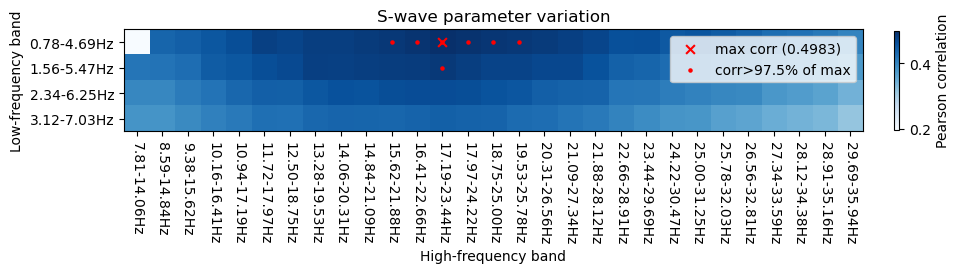

['7.81-14.06Hz', '8.59-14.84Hz', '9.38-15.62Hz', '10.16-16.41Hz', '10.94-17.19Hz', '11.72-17.97Hz', '12.50-18.75Hz', '13.28-19.53Hz', '14.06-20.31Hz', '14.84-21.09Hz', '15.62-21.88Hz', '16.41-22.66Hz', '17.19-23.44Hz', '17.97-24.22Hz', '18.75-25.00Hz', '19.53-25.78Hz', '20.31-26.56Hz', '21.09-27.34Hz', '21.88-28.12Hz', '22.66-28.91Hz', '23.44-29.69Hz', '24.22-30.47Hz', '25.00-31.25Hz', '25.78-32.03Hz', '26.56-32.81Hz', '27.34-33.59Hz', '28.12-34.38Hz', '28.91-35.16Hz', '29.69-35.94Hz']


In [20]:
pct = 0.975

# phase = 's'

# corr = np.load(f'data/corr_{phase}_big.npy')

xlabel_ticks = np.arange(0, corr.shape[1], 1)
xlabels = [f"{f[high_f_inds[el][0]]:.2f}-{f[high_f_inds[el][1]]:.2f}Hz" for el in xlabel_ticks]

ylabel_ticks = np.arange(0, corr.shape[0], 1)
ylabels = [f"{f[low_f_inds[el][0]]:.2f}-{f[low_f_inds[el][1]]:.2f}Hz" for el in ylabel_ticks]

high_inds = np.where(corr >= pct*np.max(corr))

imax, jmax = np.where(corr == np.max(corr))
print(imax, jmax)
plt.figure(figsize=(10,10))
ax = plt.gca()
im = plt.imshow(corr, cmap='Blues')
plt.scatter(jmax, imax, marker='x', color='red', s=40, label=f"max corr ({corr[imax, jmax][0]:.4f})")
plt.scatter(high_inds[1], high_inds[0], marker='o', color='red', s=5, label=f"corr>{100*pct:.1f}% of max")
cbar = plt.colorbar(im, fraction=0.046*corr.shape[0]/corr.shape[1], pad=0.04)
lbl = ax.get_xticklabels()
plt.xlabel("High-frequency band")
plt.ylabel("Low-frequency band")
ax.set_xticks(xlabel_ticks)
ax.set_xticklabels(xlabels)
plt.xticks(rotation=-90)

ax.set_yticks(ylabel_ticks)
ax.set_yticklabels(ylabels)

cbar.ax.set_ylabel("Pearson correlation")
plt.legend()
plt.title(f"{phase.upper()}-wave parameter variation")
plt.savefig(f'figs/corr/all_{phase}_correlation.pdf', bbox_inches='tight')
plt.show()

print(xlabels)

In [16]:


# compute widths of each cross section
A_len = np.sqrt(np.sum(np.power(Ap - A, 2)))
B_len = np.sqrt(np.sum(np.power(Bp - B, 2)))
A_ratio = A_len / (A_len + B_len)
B_ratio = B_len / (A_len + B_len)
gridspec_kw = {"width_ratios": [A_ratio, B_ratio]}



In [17]:

# plot the map-view and cross-sections of stress drop from Shearer et 
# al. (2022) for reference




df_plot = df_target_ev # [df_target_ev['qmag']>=2.0]
df_plot['easting'] = df_plot['qx']
df_plot['northing'] = df_plot['qy']
# df_plot = df_ev[np.logical_and(df_ev['qmag']>=1.6, df_ev['qmag']<1.8)]
# df_plot = df_ev[df_ev['qdep']<=1.0]
# df_plot = df_ev

dataname = 'dlogbeta_corr'
datatitle = r"dlogbeta"

cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8.5),
    layout='constrained')
mapout = mt.plot_map(
    df_plot,
    ax=ax,
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

mt.plot_xsection_line(A, Ap, ax, labels=["A", "A'"], linewidth=2, 
    exact_tick_length=xsec_dmax)
mt.plot_xsection_line(B, Bp, ax, labels=["B", "B'"], linewidth=2, 
    exact_tick_length=xsec_dmax)


cb_ax = fig.add_axes([1.0,.080,.028,.85])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
smap.set_clim([cnorm.vmin, cnorm.vmax])

cbar.ax.set_ylabel(datatitle)
fig.suptitle(datatitle)



fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, figsize=(11, 4),
    sharey='all', sharex='col', gridspec_kw=gridspec_kw, layout='constrained')


importlib.reload(mt)
xsecoutA = mt.plot_xsection(
    df_plot, 
    p1 = A, 
    p2 = Ap, 
    max_dist = xsec_dmax,
    ax=ax1, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    )

xsecoutB = mt.plot_xsection(
    df_plot, 
    p1 = B, 
    p2 = Bp, 
    max_dist = xsec_dmax,
    ax=ax2, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    line_name="B"
    )


fig.supylabel("Depth (km)")
fig.supxlabel("Distance along strike (km)", x=0.63)
fig.suptitle(datatitle)

# colorbar
cb_ax = fig.add_axes([1.0,.085,.02,.83])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
# smap.set_clim(clim)
# cbar.ax.set_yticks(cticks)
# cbar.ax.set_yticklabels(clabels)
cbar.ax.set_ylabel(datatitle)

# fig.canvas.draw_idle()

plt.show()




KeyError: 'dlogbeta_corr'